# Lab 2 — Digital Image Fundamentals
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook covers the lab manual:
1. **Sampling and Quantization**
2. **Arithmetic Operations** (add, subtract, add constant)
3. **Set / Logical Operations** (union, intersection, difference, symmetric difference)
4. **Practical Tasks**

> **Note on images:** The lab references `lena_gray_256.tif`, `cameraman.tif`, `A.png`, `B.png`. Since those files aren't bundled with the notebook, this notebook uses built-in `skimage` images so every cell runs out of the box. To use your own image, just replace the loading line.

## Setup

In [1]:
import cv2#for pic ,image as array
import numpy as np#for array
from PIL import Image#for pic such as resize , image as image
from skimage import data#collection of pic
import matplotlib.pyplot as plt#to show

%matplotlib inline

---
## Section 1 — Image Sampling and Quantization

- **Sampling** = how many pixels we keep (spatial resolution).
- **Quantization** = how many gray levels we keep (intensity resolution).

In [ ]:
def sample_image(image, factor):#function to downsampling,factor is to diveded pic to 2 size
    """Downsamples the image by the given factor."""
    height, width = image.shape[:2]#useallay 3 width,hight,color
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)#interpolation INTER_NEAREST
    #means take the nearst pixles 
    return sampled_image


def quantize_image(image, levels):#function for darkinning image (gray color level)
    """Reduces the number of grayscale levels in the image."""
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)#rand down
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):#to display
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1), plt.imshow(original, cmap='gray')
    plt.title('Original Image'), plt.axis('off')
    plt.subplot(1, 3, 2), plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image'), plt.axis('off')
    plt.subplot(1, 3, 3), plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image'), plt.axis('off')
    plt.show()

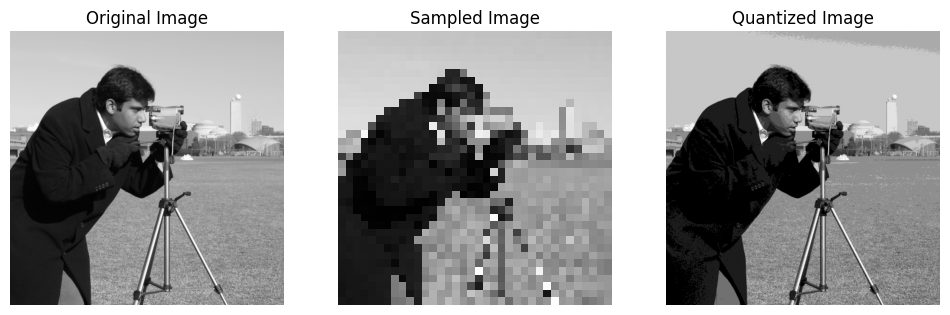

In [ ]:
original_image = data.camera()

sampling_factor = 14
quantization_levels = 9#gray level

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image#most darkness)#as much as we inc level > more darkness

---
## Section 2 — Arithmetic Operations

Add two images by converting them to numpy arrays and adding element-wise.

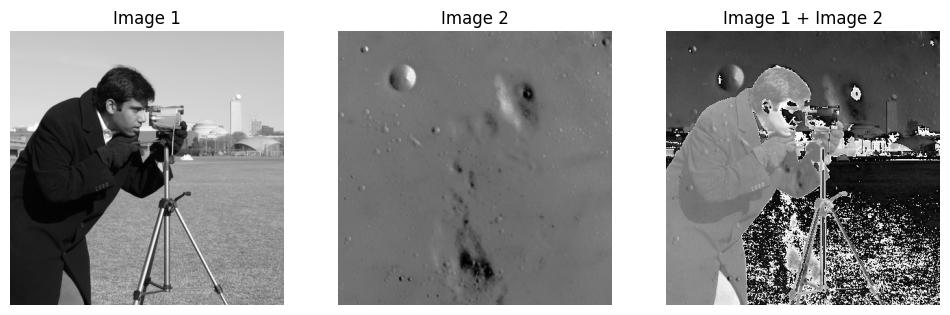

In [ ]:
img1 = Image.fromarray(data.camera())#convert array to images so that we can use the resize
img2 = Image.fromarray(data.moon())

new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS)
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)#based on LANCZOS nearest by calculation butter than inter nearest

im1arr = np.asarray(img1)#returen aas array so thet we can add them 
im2arr = np.asarray(img2)

addition = im1arr + im2arr
result_image = Image.fromarray(addition)#convert array to images to display it

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 + Image 2'), plt.axis('off')
plt.show()

---
## Section 3 — Set / Logical Operations

Pixel-wise bitwise operations on two images. Lab demo: **union (OR)**.

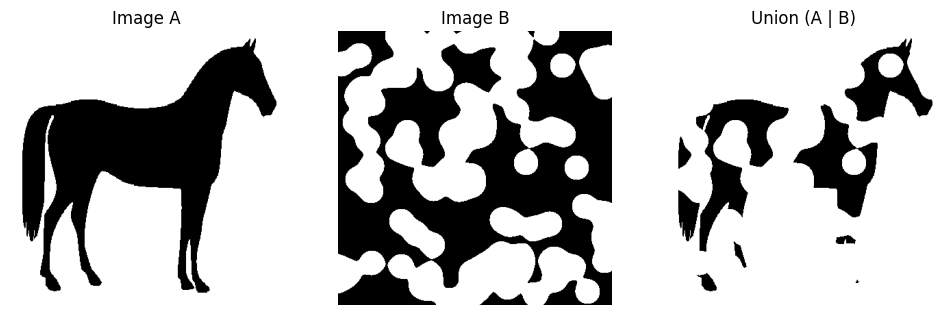

In [ ]:
img3 = Image.fromarray(data.horse())#convert to images
img4 = Image.fromarray(data.binary_blobs(length=400))

img3 = img3.resize(new_size, Image.Resampling.LANCZOS)
img4 = img4.resize(new_size, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)#reteurn as array to caculate
im4arr = np.asarray(img4)

union = im4arr | im3arr
result_image_2 = Image.fromarray(union)#convert to images tp display

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('Union (A | B)'), plt.axis('off')
plt.show()

---
# Practical Tasks

## Task 1 — Change sampling and quantization parameters and observe the effects

Try multiple values of the sampling factor and the number of quantization levels to see how each affects the image.

### 1a) Effect of sampling factor (spatial resolution)

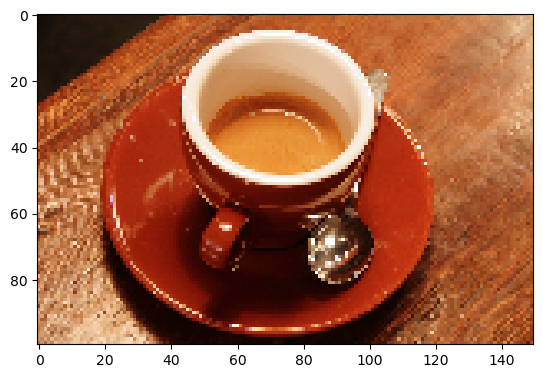

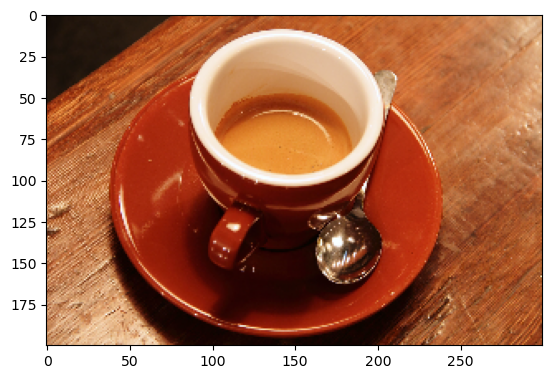

In [11]:
#As much as sampling factor becomes larger,fewer pixels are kept.
#so the image loses spatial detail and  image quality decreases. 

from skimage import data
import matplotlib.pyplot as plt

img = data.coffee()

small = img[::2, ::2]  
img = data.coffee()
small2 = img[::4, ::4]
img = data.coffee()

plt.imshow(small2)
plt.show()
plt.imshow(small)
plt.show()

### 1b) Effect of quantization levels (intensity resolution)

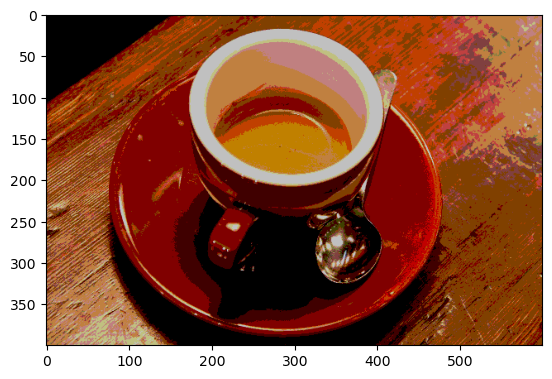

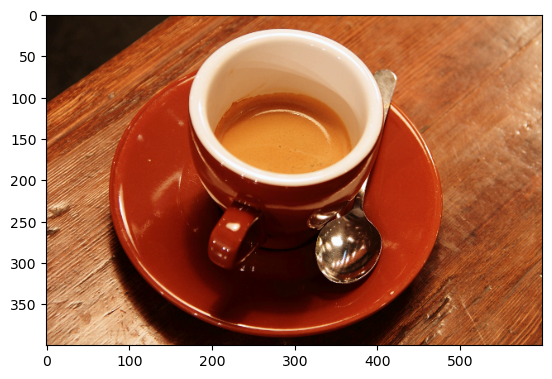

In [16]:
#As the number of quantization levels decreases, image quality decreases. 
#The image has fewer intensity values, causing loss of detail .
levels = 4
quantized = (img // (256 // levels)) * (256 // levels)
levels = 64
quantized2 = (img // (256 // levels)) * (256 // levels)

plt.imshow(quantized, cmap='gray')
plt.show()

plt.imshow(quantized2, cmap='gray')
plt.show()

---
## Task 2 — Image Arithmetic and Set Operations

Required operations:
1. Subtract two images and display the result
2. Add one image with a constant value 175
3. Set difference on two grayscale images
4. Symmetric difference on two grayscale images
5. Intersection on two grayscale images

### 2a) Subtract two images

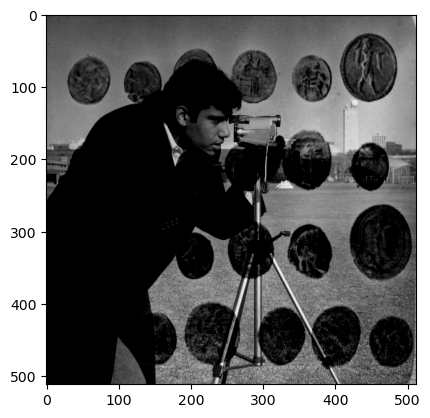

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

img1 = data.camera()
img2 = data.coins()

img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

sub = cv2.subtract(img1, img2)

plt.imshow(sub, cmap='gray')
plt.show()

### 2b) Add image with constant value 175

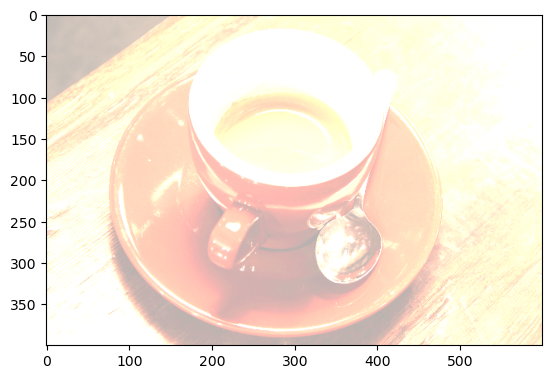

In [20]:
add = cv2.add(img, 175)

plt.imshow(add, cmap='gray')
plt.show()

### 2c-2e) Set operations on grayscale images

| Operation | Bitwise formula | Meaning |
|---|---|---|
| **Intersection** | `A & B` | bits set in both |
| **Set difference** | `A & ~B` (A − B) | bits in A but not in B |
| **Symmetric difference** | `A ^ B` | bits in A or B but not both |
| **Union** (extra) | `A \| B` | bits in either |

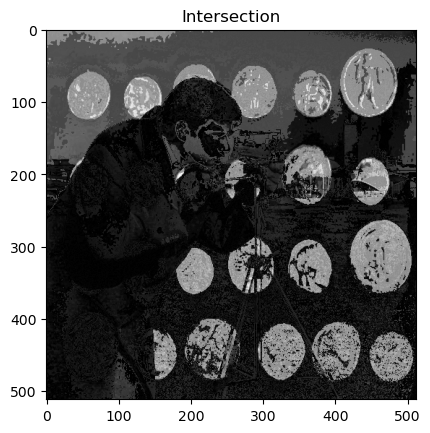

In [26]:
intersection = cv2.bitwise_and(img1, img2)

plt.imshow(intersection, cmap='gray')
plt.title("Intersection")
plt.show()

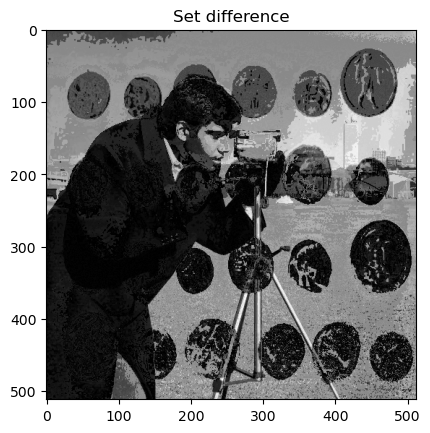

In [27]:
difference = cv2.bitwise_and(img1, cv2.bitwise_not(img2))

plt.imshow(difference, cmap='gray')
plt.title("Set difference")
plt.show()

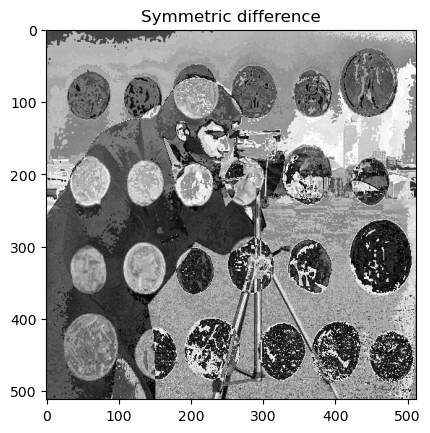

In [25]:
sym_diff = cv2.bitwise_xor(img1, img2)

plt.imshow(sym_diff, cmap='gray')
plt.title("Symmetric difference")
plt.show()

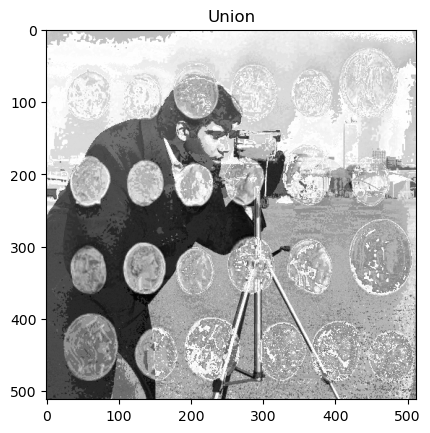

In [24]:
union = cv2.bitwise_or(img1, img2)

plt.imshow(union, cmap='gray')
plt.title("Union")
plt.show()
